# P.1 — GPS Tracking: What the Numbers Actually Mean

Introduction to physical performance metrics in football.
Synthetic dataset based on published benchmarks (Mohr et al. 2003, Bradley et al. 2009, Di Salvo et al. 2007).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATA    = '../assets/physical_data_synthetic.csv'
FIGURES = 'figures'

df = pd.read_csv(DATA)
print(f'Rows: {len(df)}')
print(f'Matches: {df["match_id"].nunique()}')
print(f'Players: {df["player_id"].nunique()}')
print(f'Teams: {df["team"].nunique()}')

Rows: 9880
Matches: 380
Players: 260
Teams: 20


---
## Overview: Columns and Basic Stats

In [2]:
print(df.columns.tolist())
df.head(5)

['match_id', 'team', 'opponent', 'is_home', 'player_id', 'player_name', 'position', 'minutes_played', 'total_distance', 'mmin', 'running_distance', 'hsr_distance', 'sprinting_distance', 'hi_distance', 'count_hsr', 'count_sprint', 'count_hi', 'count_medium_acceleration', 'count_high_acceleration', 'count_medium_deceleration', 'count_high_deceleration', 'max_speed']


,match_id,team,opponent,is_home,player_id,player_name,position,minutes_played,total_distance,mmin,...,sprinting_distance,hi_distance,count_hsr,count_sprint,count_hi,count_medium_acceleration,count_high_acceleration,count_medium_deceleration,count_high_deceleration,max_speed
0,1000,Newcastle United,Arsenal,True,183,Player 183,Goalkeeper,90,5915.5,65.7,...,24.0,154.8,0,4,10,61,6,51,17,27.76
1,1000,Newcastle United,Arsenal,True,184,Player 184,Center Back,73,10017.3,137.2,...,98.5,424.1,17,6,32,76,13,51,10,34.15
2,1000,Newcastle United,Arsenal,True,185,Player 185,Center Back,59,6874.1,116.5,...,94.0,319.6,16,8,8,102,9,47,10,34.62
3,1000,Newcastle United,Arsenal,True,186,Player 186,Full Back,69,7846.5,113.7,...,69.0,289.6,48,19,42,96,20,150,19,34.32
4,1000,Newcastle United,Arsenal,True,187,Player 187,Full Back,57,7104.6,124.6,...,147.3,517.3,9,15,29,128,20,83,16,32.28


In [3]:
starters = df[df['minutes_played'] >= 80]
print(f'Full-game appearances (>=80 min): {len(starters)}')
starters[['total_distance','sprinting_distance','max_speed','count_high_acceleration','mmin']].describe().round(1)

Full-game appearances (>=80 min): 7768


,total_distance,sprinting_distance,max_speed,count_high_acceleration,mmin
count,7768.0,7768.0,7768.0,7768.0,7768.0
mean,10733.3,190.8,31.8,24.5,119.8
std,1807.9,126.0,2.6,10.5,20.0
min,3827.4,0.0,22.6,0.0,42.5
25%,10108.2,87.7,30.1,17.0,113.2
50%,11075.9,177.8,31.9,24.0,123.6
75%,11854.5,278.5,33.6,32.0,132.2
max,14765.0,701.9,40.6,65.0,165.4


---
## Position Profiles — 6 Metrics

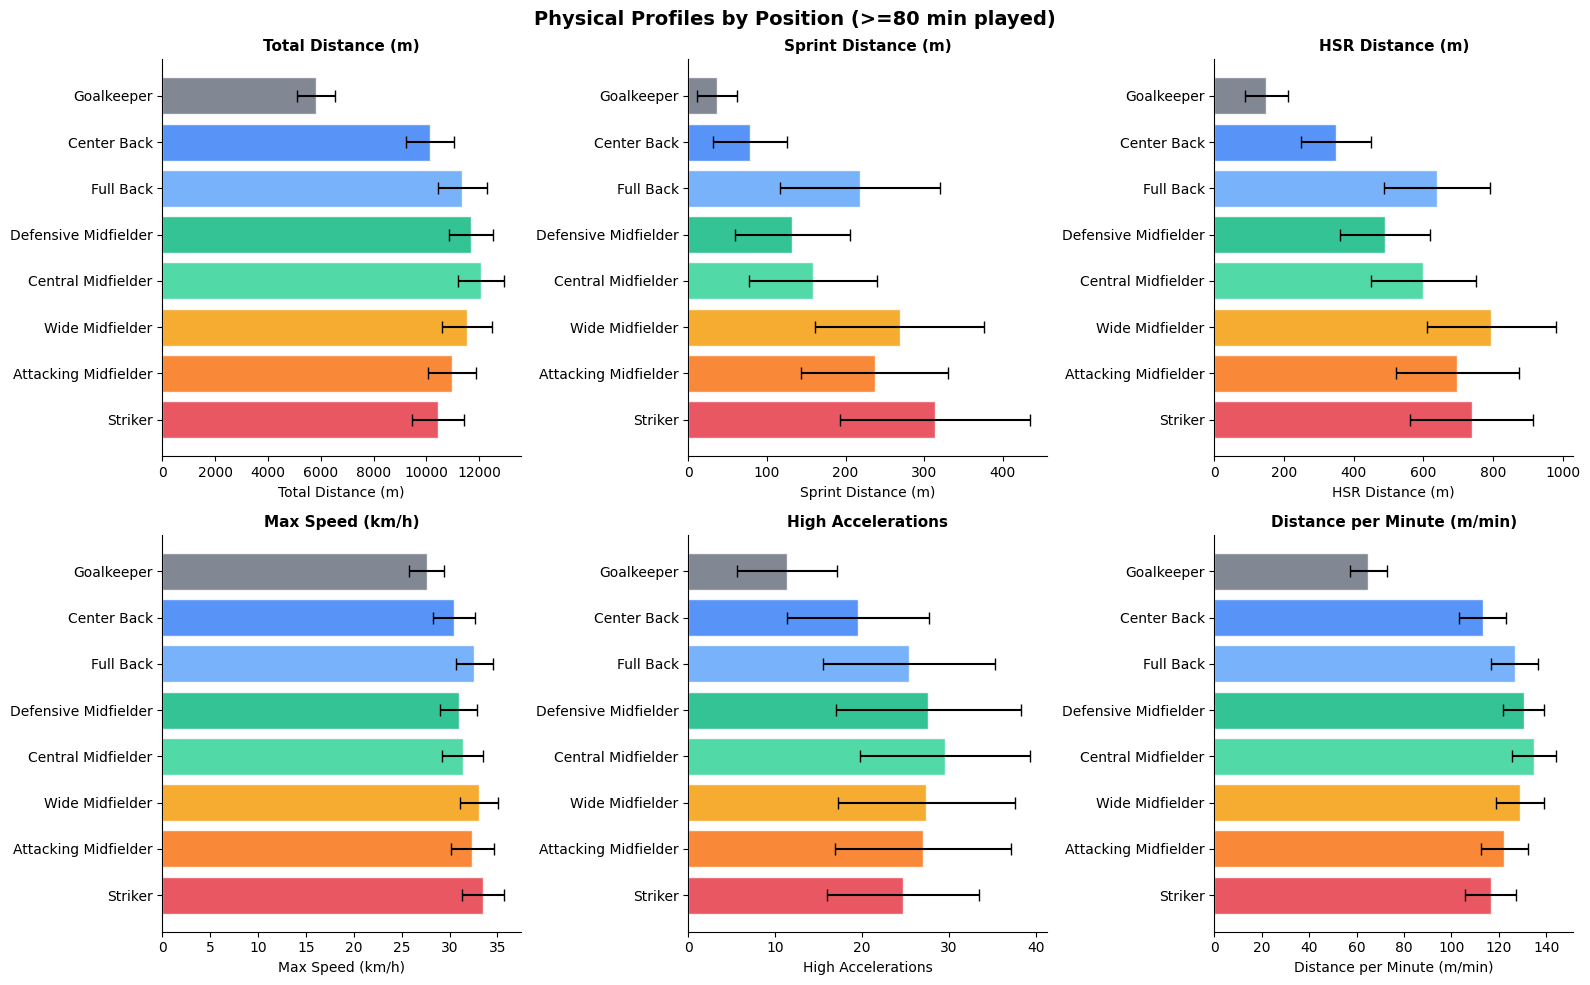

In [4]:
pos_order = [
    'Goalkeeper','Center Back','Full Back',
    'Defensive Midfielder','Central Midfielder',
    'Wide Midfielder','Attacking Midfielder','Striker'
]
colors = ['#6b7280','#3b82f6','#60a5fa','#10b981','#34d399','#f59e0b','#f97316','#e63946']

metrics = [
    ('total_distance',         'Total Distance (m)'),
    ('sprinting_distance',     'Sprint Distance (m)'),
    ('hsr_distance',           'HSR Distance (m)'),
    ('max_speed',              'Max Speed (km/h)'),
    ('count_high_acceleration','High Accelerations'),
    ('mmin',                   'Distance per Minute (m/min)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Physical Profiles by Position (>=80 min played)', fontweight='bold', fontsize=14)

for ax, (col, label) in zip(axes.flat, metrics):
    means = starters.groupby('position')[col].mean().reindex(pos_order)
    stds  = starters.groupby('position')[col].std().reindex(pos_order)
    ax.barh(pos_order, means, xerr=stds, color=colors,
            alpha=0.85, edgecolor='white', capsize=4)
    ax.set_xlabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES}/position_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Distance Distribution by Position

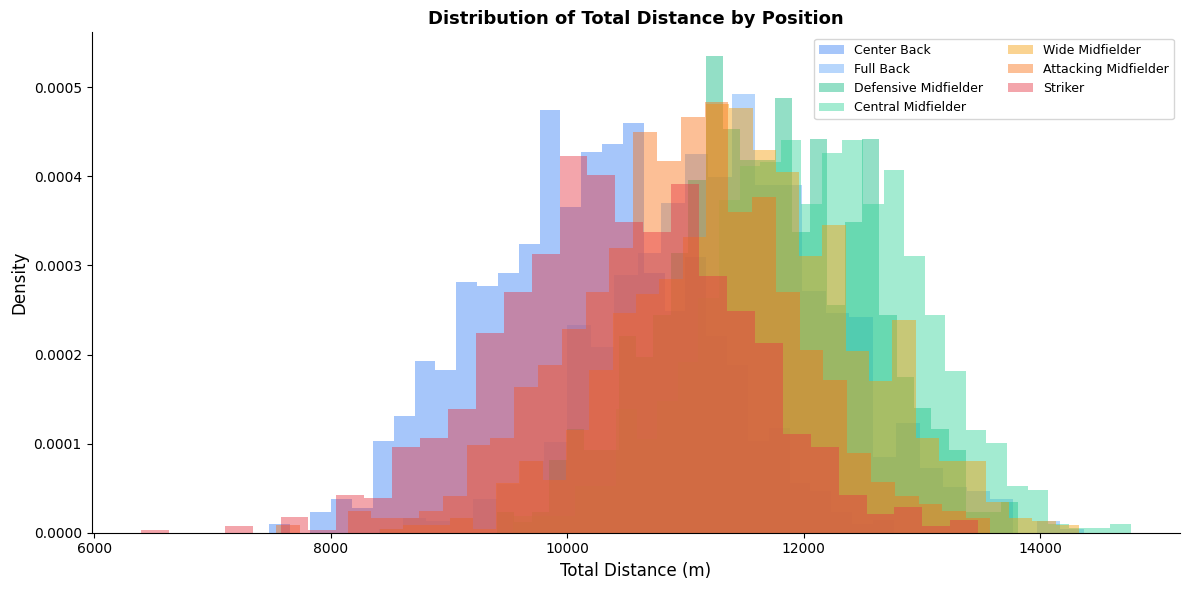

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for pos, color in zip(pos_order[1:], colors[1:]):
    data = starters[starters['position'] == pos]['total_distance']
    ax.hist(data, bins=30, alpha=0.45, color=color, label=pos, density=True)

ax.set_xlabel('Total Distance (m)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Total Distance by Position', fontweight='bold', fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/distance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Meters per Minute by Position

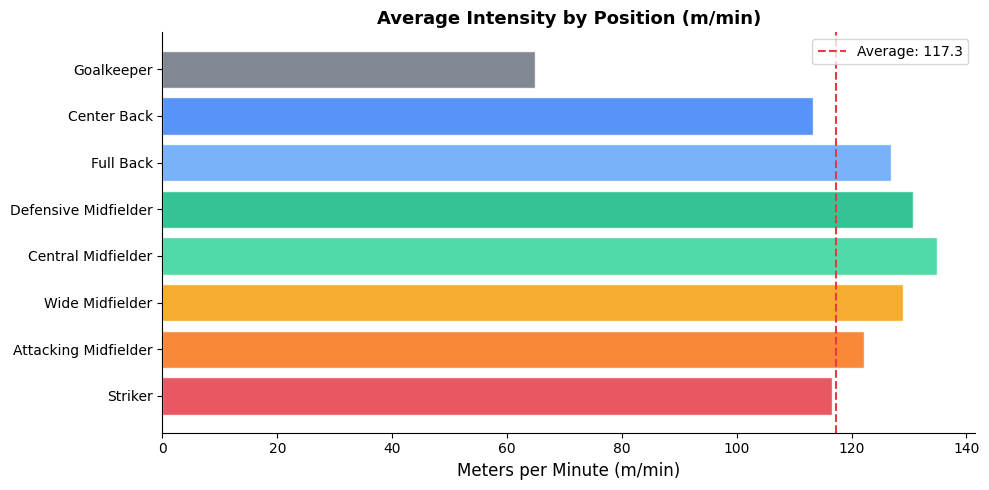

In [6]:
starters_and_subs = df[df['minutes_played'] >= 20]
by_pos = starters_and_subs.groupby('position')['mmin'].mean().reindex(pos_order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pos_order, by_pos, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Meters per Minute (m/min)', fontsize=12)
ax.set_title('Average Intensity by Position (m/min)', fontweight='bold', fontsize=13)
ax.invert_yaxis()
ax.axvline(by_pos.mean(), color='#e63946', linestyle='--', linewidth=1.5, label=f'Average: {by_pos.mean():.1f}')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/mmin_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

---
**Next: [P.2 — Sprint Profiles](../P.2_Sprint_Profiles/notebook.ipynb)**